### Leitura
Lê o CSV e retorna a lista de transações brutas

In [91]:
import csv

def ler_transacoes(file_name):
    try:
        with open(file_name, mode='r', newline='', encoding='utf-8') as file:
            return list(csv.DictReader(file))

    except FileNotFoundError:
        return print("Arquivo não encontrado.")
    except Exception as e:
        return print("Erro ", e)

### Validacao
Valida uma única linha e retorna o registro limpo

- id	inteiro	Identificador único da transação

- data	texto	Data no formato AAAA-MM-DD

- cliente_id	texto	Código do cliente (não pode ser vazio)

- tipo	texto	credito ou debito

- valor	decimal	Valor da transação (deve ser maior que 0)

- descricao	texto	Descrição livre da operação

- categoria	texto	Ex.: salario, compra, transferencia

In [97]:
from datetime import datetime


def validar_transacao(row):

    def valid_id(id):
        if isinstance(id, type(float('nan'))):
            return False
        if isinstance(id, int):
            return True
        return False
    
    def valid_client_id(id):
        if isinstance(id, type(float('nan'))):
            return False
        return True

    def valid_transaction_type(transaction_type):
        if transaction_type in ('debito', 'credito'):
            return True
        return False

    def valid_value(value):
        if value > 0:
            return True
        return False

    def invalid_input(value, target_type, default=None):
        try:
            return target_type(value)
        except (ValueError, TypeError):
            return default

    if not invalid_input(row['id'], int):
        return None
    else:
        id = int(row['id'])
        if not valid_id(id):
            return None

    if not invalid_input(row['cliente_id'], str):
        return None
    else:
        client_id = row['cliente_id']
        if not valid_client_id(client_id):
            return None

    try:
        date = datetime.strptime(row['data'], "%Y-%m-%d")
    except (ValueError, TypeError):
        return None

    if not valid_transaction_type(row['tipo']):                                                                                                                    
        return None
       
    if not invalid_input(row['valor'], float):
        return None
    else:
        value = float(row['valor'])         
        if not valid_value(value):
            return None
        
    return [id, date, client_id, row['tipo'], value, row['descricao'], row['categoria']]


## Datas
Calcule quantos dias se passaram desde a transação mais antiga e a mais recente presentes nos dados.

In [116]:

def getMonths(dates):
    months = []
    for date in dates:
        if date not in months:
            month = datetime.strftime(date, "%Y-%m")
            months.append(month)

    months = sorted(set(months))
    return months



## Métricas
Agrupa os dados e calcula as métricas

Para cada mês presente nos dados, calcule:

* Quantidade total de transações.
* Soma dos valores de transações do tipo credito.
* Soma dos valores de transações do tipo debito.
* Saldo do mês (credito - debito).
* Valor médio por transação.
* Transação de maior valor no mês.
* Transação de menor valor no mês.

In [171]:

def gerar_relatorio(dataset):

    dates = list(zip(*dataset))[:][1]
    months = getMonths(dates)
    
    sustransactions = []
    report = dict()
    for month in months:
        monthlyReport = dict()
        credito = []
        debito = []
        for row in dataset:
            if row[1].strftime('%Y-%m') == month:
                if row[4] > LIMITE_SUSPEITO: 
                    date = datetime.strftime(row[1], "%Y-%m-%d")
                    sustransactions.append(
                        {
                        "id": row[0],
                        "cliente_id": row[2],
                        "data": date,
                        "valor": row[4]
                        }
                    )
                    continue

                elif row[3] == 'credito':
                    credito.append(row[4])
                elif row[3] == 'debito':
                    debito.append(row[4])
                
                total_credito = sum(credito)
                total_debito = sum(debito)

                saldo = total_credito - total_debito
                media = (total_credito + total_debito) / (len(credito) + len(debito))
                maior_valor = max(credito + debito)
                menor_valor = min(credito + debito)

        monthlyReport = {
            "quantidade": len(credito) + len(debito),
            "total_credito": total_credito,
            "total_debito": total_debito,
            "saldo": saldo,
            "media": media,
            "maior_valor": maior_valor,
            "menor_valor": menor_valor
        }

        report[month] = monthlyReport

    return report, sustransactions

## JSON
Salva o resultado no arquivo relatorio.json




{
  "gerado_em": "2026-05-14",
  "total_transacoes_validas": 6,
  "total_transacoes_invalidas": 2,
  "resumo_mensal": {
    "2026-01": {
      "quantidade": 2,
      "total_credito": 3500.00,
      "total_debito": 180.50,
      "saldo": 3319.50,
      "media": 1840.25,
      "maior_valor": 3500.00,
      "menor_valor": 180.50
    }
  },
  "transacoes_suspeitas": [
    {
      "id": 5,
      "cliente_id": "CLI003",
      "data": "2026-02-14",
      "valor": 15000.00
    }
  ]
}

In [93]:

import json

def salvar_json(reports, stats, sustransactions):

    reportDate = datetime.now().strftime("%Y-%m")
    jsonDict = dict()

    jsonDict["gerado_em"]= str(reportDate)
    jsonDict["total_transacoes_validas"] = stats['valid']
    jsonDict["total_transacoes_invalidas" ]= stats['invalid']
    jsonDict["resumo_mensal"] = dict(reports)
    jsonDict["transacoes_suspeitas"] = sustransactions    
    
    with open('relatorio.json', 'w', encoding='utf-8') as f:
        json.dump(jsonDict, f, ensure_ascii=False, indent=2)

    return 0


## Relatório
Formata e imprime os resultados no terminal

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 2
  Total crédito: R$ 3.500,00
  Total débito:  R$ 180,50
  Saldo:         R$ 3.319,50
  Média:         R$ 1.840,25
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 180,50


Qualquer transação com valor acima desse limite deve ser marcada como suspeita. Ao final do relatório, liste as transações suspeitas com id, cliente_id, data e valor.

Exemplo:

===== TRANSAÇÕES SUSPEITAS =====
ID: 5 | Cliente: CLI003 | Data: 2026-02-14 | Valor: R$ 15.000,00
Se não houver transações suspeitas, exiba: Nenhuma transação suspeita encontrada.



In [102]:


def exibir_relatorio(report, sustransactions):
    def freais(value):
        return f"R$ {value:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    for mes, data in report.items():
        print(f"===== RELATÓRIO MENSAL =====")
        print(f"Mês: {mes}")
        print(f"  Transações:  \t{data['quantidade']}")
        print(f"  Total crédito: {freais(data['total_credito'])}")
        print(f"  Total débito:  {freais(data['total_debito'])}")
        print(f"  Saldo:  \t {freais(data['saldo'])}")
        print(f"  Média:  \t {freais(data['media'])}")
        print(f"  Maior valor: \t {freais(data['maior_valor'])}")
        print(f"  Menor valor: \t {freais(data['menor_valor'])}")

    if sustransactions == []:
        print("Nenhuma transação suspeita encontrada.")
    else:
        print(f"===== TRANSAÇÕES SUSPEITAS =====")
        for logs in sustransactions:
            print(f"ID: {logs['id']} | Cliente: {logs['cliente_id']} | Data: {logs['data']} | Valor: {freais(logs['valor'])}")
        

    return 0

## Validação Final

In [174]:
LIMITE_SUSPEITO = 10000.00

invalid = 0
dataset = []


file_name='transacoes.csv'

raw_file = ler_transacoes(file_name)

for row in raw_file:
    if validar_transacao(row) is not None:
        dataset.append(validar_transacao(row))
    else:
        invalid += 1

print("Total de linhas lidas", len(raw_file))
print("Total de linhas válidas", len(dataset))
print("Total de linhas inválidas", invalid)


stats = dict()
stats['valid'] = len(dataset)
stats['invalid'] = invalid
report, sustransactions = gerar_relatorio(dataset)

salvar_json(report, stats, sustransactions)
exibir_relatorio(report, sustransactions)

Total de linhas lidas 52
Total de linhas válidas 47
Total de linhas inválidas 5
===== RELATÓRIO MENSAL =====
Mês: 2026-01
  Transações:  	6
  Total crédito: R$ 3.500,00
  Total débito:  R$ 875,40
  Saldo:  	 R$ 2.624,60
  Média:  	 R$ 729,23
  Maior valor: 	 R$ 3.500,00
  Menor valor: 	 R$ 45,00
===== RELATÓRIO MENSAL =====
Mês: 2026-02
  Transações:  	8
  Total crédito: R$ 3.500,00
  Total débito:  R$ 2.144,60
  Saldo:  	 R$ 1.355,40
  Média:  	 R$ 705,58
  Maior valor: 	 R$ 3.500,00
  Menor valor: 	 R$ 60,00
===== RELATÓRIO MENSAL =====
Mês: 2026-03
  Transações:  	7
  Total crédito: R$ 6.300,00
  Total débito:  R$ 1.077,35
  Saldo:  	 R$ 5.222,65
  Média:  	 R$ 1.053,91
  Maior valor: 	 R$ 3.500,00
  Menor valor: 	 R$ 85,00
===== RELATÓRIO MENSAL =====
Mês: 2026-04
  Transações:  	8
  Total crédito: R$ 8.000,00
  Total débito:  R$ 1.200,00
  Saldo:  	 R$ 6.800,00
  Média:  	 R$ 1.150,00
  Maior valor: 	 R$ 4.500,00
  Menor valor: 	 R$ 65,00
===== RELATÓRIO MENSAL =====
Mês: 2026-05


0

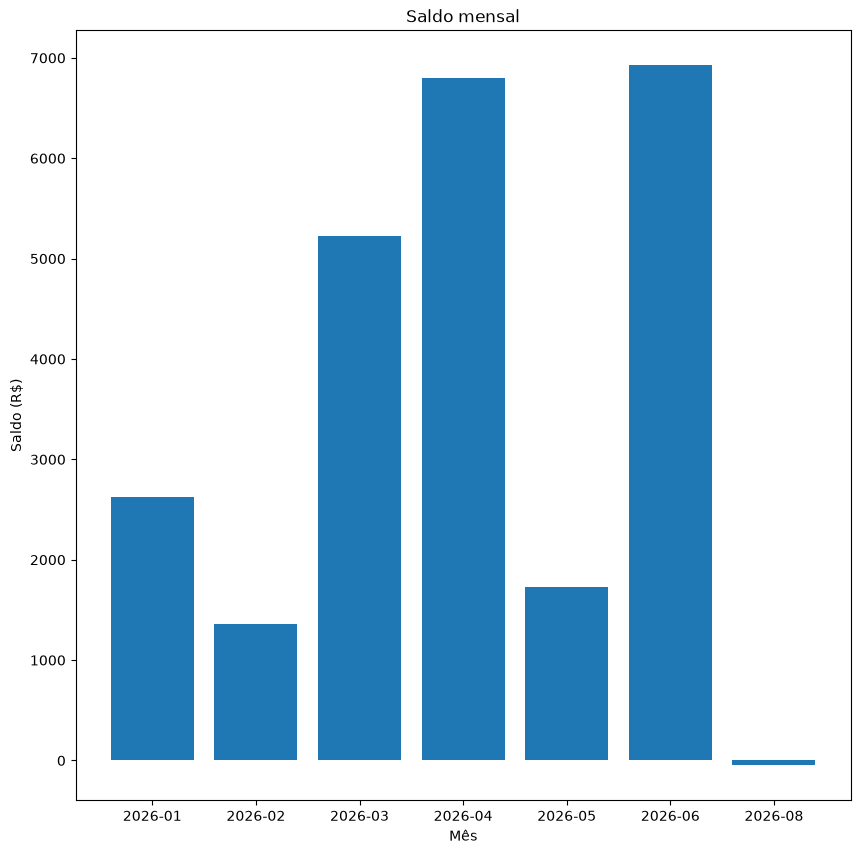

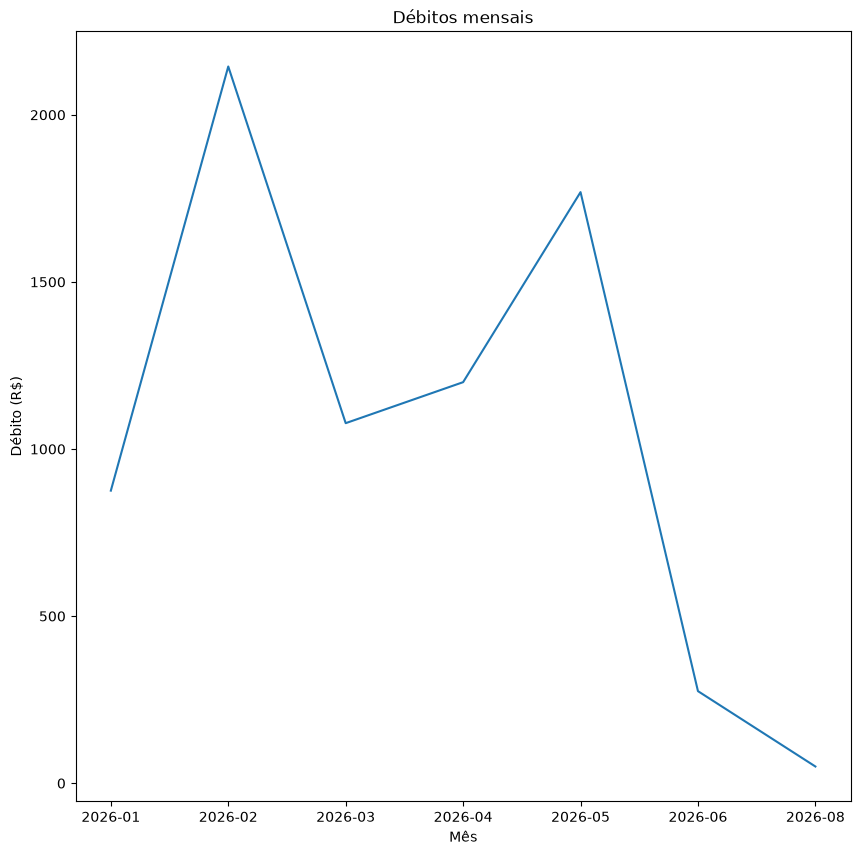

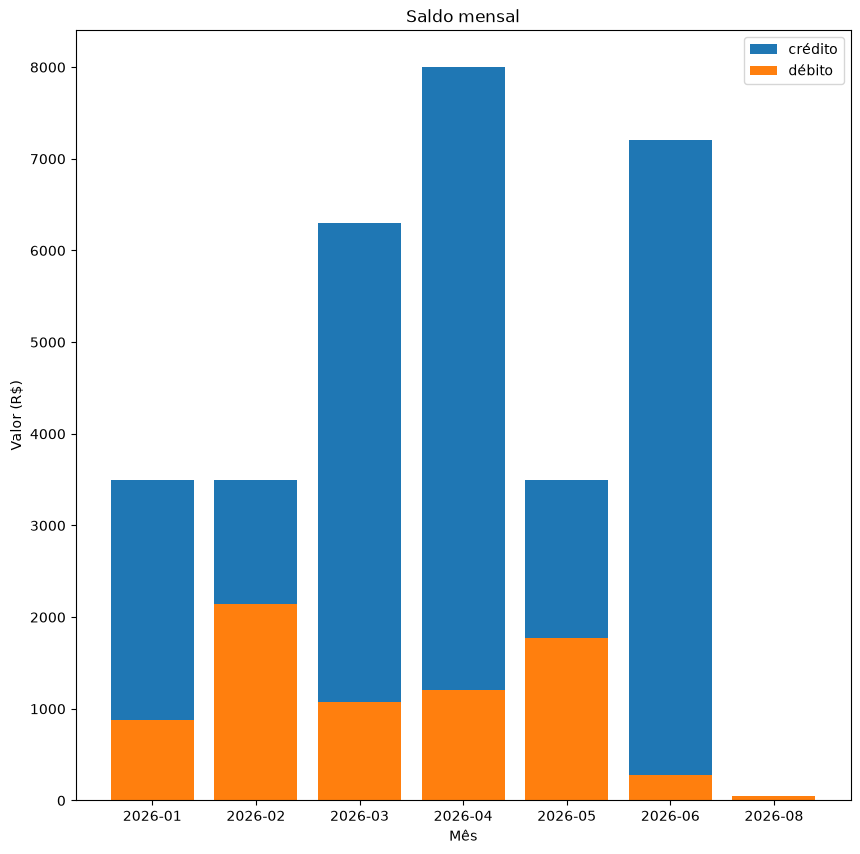

In [175]:

import matplotlib.pyplot as plt

month = report.keys()
saldo = [month_data['saldo'] for month_data in report.values() if 'saldo' in month_data]
total_debitos = [month_data['total_debito'] for month_data in report.values() if 'total_debito' in month_data]
total_credito = [month_data['total_credito'] for month_data in report.values() if 'total_credito' in month_data]


fig = plt.figure(figsize=(10, 10))
plt.bar(month, saldo)

plt.title("Saldo mensal")
plt.xlabel("Mês")
plt.ylabel("Saldo (R$)")
plt.show()
fig.savefig('grafico.png')



fig = plt.figure(figsize=(10, 10))

plt.plot(month, total_debitos)

plt.title("Débitos mensais")
plt.xlabel("Mês")
plt.ylabel("Débito (R$)")
plt.show()
fig.savefig('grafico2.png')


fig = plt.figure(figsize=(10, 10))

plt.bar(month, total_credito, label='crédito')
plt.bar(month, total_debitos, label='débito')

plt.title("Saldo mensal")
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.legend()
plt.show()

fig.savefig('grafico3.png')